# Text Mining Project — Market Sentiment Classification
**Spring Semester 2025/2026 | NOVA IMS**

Classifying financial tweets into three sentiment categories:
- **0 — Bearish** (negative / pessimistic)
- **1 — Bullish** (positive / optimistic)
- **2 — Neutral**

---
<a class='anchor' id='toc'></a>
## Table of Contents

1. [Setup & Imports](#1)
2. [Data Exploration](#2)
   - [2.1 Dataset Overview & Duplicates](#2-1)
   - [2.2 Class Distribution](#2-2)
   - [2.3 Tweet Length Analysis](#2-3)
   - [2.4 Global Vocabulary](#2-4)
   - [2.5 Top Words per Class](#2-5)
   - [2.6 Financial Sentiment Words](#2-6)
   - [2.7 N-gram Analysis (Bigrams & Trigrams)](#2-7)
   - [2.8 Special Features (Hashtags, Mentions, URLs)](#2-8)
   - [2.9 Top Hashtags & Cashtags per Class](#2-9)
   - [2.10 Tweets with Little Content After Cleaning](#2-10)
   - [2.11 Exclusive Vocabulary per Class](#2-11)
   - [2.12 Lexical Dispersion](#2-12)
   - [2.13 Co-occurrence Heatmap](#2-13)
   - [2.14 Tweet Length Boxplot & Statistical Test](#2-14)
   - [2.15 Exploration Summary & Conclusions](#2-15)
3. [Data Preprocessing](#3)
   - [3.1 Step-by-step Demonstration](#3-1)
   - [3.2 Lemmatization vs Stemming](#3-2)
   - [3.3 Preprocessing Functions](#3-3)
   - [3.4 Apply to Full Training Set](#3-4)
   - [3.5 Before / After Comparison](#3-5)
   - [3.6 Vocabulary Impact](#3-6)
   - [3.7 Empty Tweets After Cleaning](#3-7)
4. [Corpus Split — Stratified K-Fold](#4)
5. [Feature Engineering](#5)
   - [5.1 BoW & TF-IDF](#5-1)
   - [5.2 Word2Vec](#5-2)
   - [5.3 Transformer Encoder Embeddings](#5-3)
6. [Classification Models](#6)
   - [6.1 Evaluation Helper](#6-1)
   - [6.2 Traditional ML — TF-IDF Pipeline](#6-2)
   - [6.3 Traditional ML — Word2Vec Pipeline](#6-3)
   - [6.4 Transformer Encoder + Classifier Head](#6-4)
   - [6.5 Fine-tuned FinBERT (End-to-end)](#6-5)
7. [Evaluation & Analysis](#7)
8. [Final Predictions on test.csv](#8)

<a class='anchor' id='1'></a>
---
## 1. Setup & Imports

In [1]:
!pip install nltk gensim xgboost wordsegment -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import re, string, warnings
warnings.filterwarnings('ignore')

import nltk
for pkg in ['stopwords','punkt','punkt_tab','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.util import ngrams

STOP         = set(stopwords.words('english'))
lemma        = WordNetLemmatizer()
stemmer      = SnowballStemmer('english')
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
CLASS_NAMES  = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}

print('✅ Imports OK')

✅ Imports OK


[↑ Back to TOC](#toc)

<a class='anchor' id='2'></a>
---
## 2. Data Exploration

<a class='anchor' id='2-1'></a>
### 2.1 Dataset Overview & Duplicates

In [3]:
df = pd.read_csv('train.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(10)

Shape: (9543, 2)
Columns: ['text', 'label']

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


In [4]:
dup_text = df.duplicated(subset='text').sum()
dup_both = df.duplicated(subset=['text','label']).sum()
print(f'Duplicate tweets (same text):         {dup_text}')
print(f'Duplicate tweets (same text+label):   {dup_both}')
if dup_text > 0:
    mask = df.duplicated(subset='text', keep=False)
    conflicts = df[mask].groupby('text')['label'].nunique()
    conflicts = conflicts[conflicts > 1]
    print(f'\nConflicting labels (same text, diff label): {len(conflicts)}')
    if len(conflicts) > 0:
        print(df[df['text'].isin(conflicts.index)][['text','label']].head(8).to_string())

Duplicate tweets (same text):         0
Duplicate tweets (same text+label):   0


[↑ Back to TOC](#toc)

<a class='anchor' id='2-2'></a>
### 2.2 Class Distribution

Important to detect imbalance — if ~40% of tweets are Neutral the model may default to predicting Neutral.

=== Tweet count per class ===
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


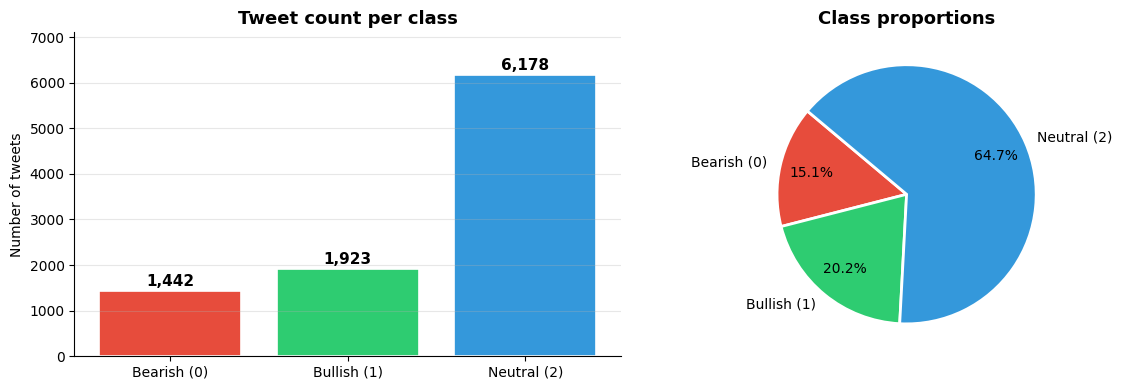


⚠️  Majority-class baseline: 64.7% — any model must beat this.


In [5]:
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)
print('=== Tweet count per class ===')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Tweet count per class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class proportions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
majority_acc = label_counts.max() / len(df) * 100
print(f'\n⚠️  Majority-class baseline: {majority_acc:.1f}% — any model must beat this.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-3'></a>
### 2.3 Tweet Length Analysis

=== Length statistics ===
       n_chars  n_words
count   9543.0   9543.0
mean      85.9     12.2
std       35.1      4.7
min        2.0      1.0
25%       58.0      9.0
50%       79.0     11.0
75%      120.0     15.0
max      190.0     32.0


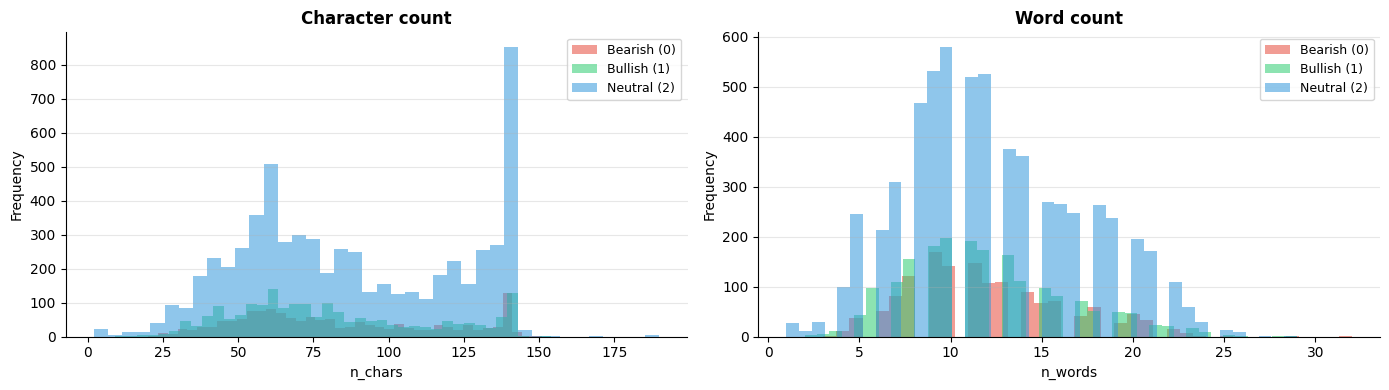


=== Average length per class ===
             n_chars  n_words
label                        
Bearish (0)     83.4     12.0
Bullish (1)     80.4     11.9
Neutral (2)     88.1     12.3


In [6]:
df['n_chars']  = df['text'].str.len()
df['n_words']  = df['text'].str.split().str.len()
df['n_tokens'] = df['text'].apply(lambda x: len(word_tokenize(str(x))))

print('=== Length statistics ===')
print(df[['n_chars','n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for metric, ax, title in [('n_chars', axes[0], 'Character count'), ('n_words', axes[1], 'Word count')]:
    for lbl in [0,1,2]:
        ax.hist(df[df['label']==lbl][metric], bins=40, alpha=0.55,
                color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric); ax.set_ylabel('Frequency')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('\n=== Average length per class ===')
print(df.groupby('label')[['n_chars','n_words']].mean().round(1).rename(index=CLASS_NAMES))

[↑ Back to TOC](#toc)

<a class='anchor' id='2-4'></a>
### 2.4 Global Vocabulary

In [7]:
def tokenize_explore(text):
    """Lightweight tokeniser for exploration only — no model fitting."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_explore(txt))

vocab = set(all_tokens)
freq  = Counter(all_tokens)
top50 = freq.most_common(50)

print(f'Total tokens (no stopwords): {len(all_tokens):,}')
print(f'Unique vocabulary:           {len(vocab):,}')
print('\nTop 20 most frequent words:')
for word, cnt in top50[:20]:
    print(f'   {word:<20} {cnt:>5}')

Total tokens (no stopwords): 73,385
Unique vocabulary:           14,016

Top 20 most frequent words:
   stock                  611
   new                    417
   results                374
   market                 359
   says                   349
   earnings               346
   inc                    316
   china                  311
   dividend               292
   price                  290
   stocks                 279
   year                   274
   reports                259
   trade                  252
   buy                    237
   deal                   234
   oil                    233
   shares                 223
   revenue                218
   beats                  209


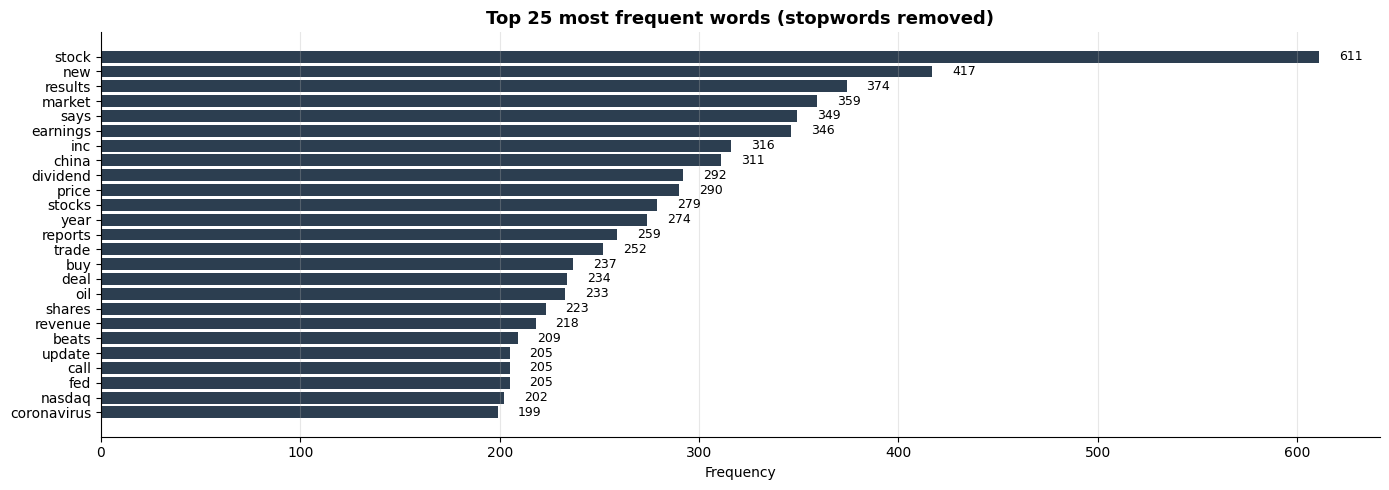

In [8]:
top25_words, top25_counts = zip(*top50[:25])
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('Top 25 most frequent words (stopwords removed)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-5'></a>
### 2.5 Top Words per Class (Relative Frequency)

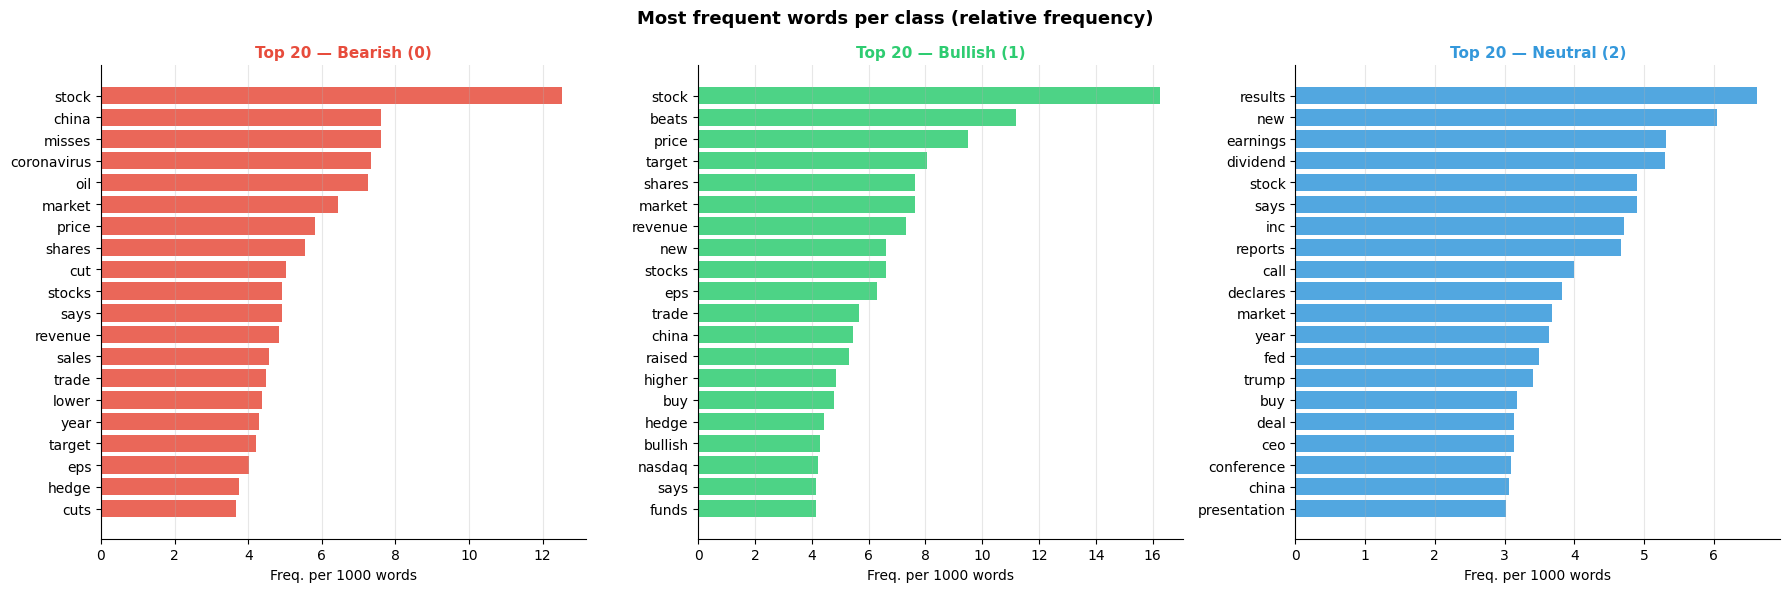

In [9]:
tokens_per_class = {}
for lbl in [0,1,2]:
    toks = []
    for txt in df[df['label']==lbl]['text']:
        toks.extend(tokenize_explore(txt))
    tokens_per_class[lbl] = Counter(toks)

total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0,1,2], axes):
    rel = {w: cnt/total_per_class[lbl]*1000
           for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top = sorted(rel, key=rel.get, reverse=True)[:20]
    ax.barh(list(reversed(top)), [rel[w] for w in reversed(top)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. per 1000 words'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Most frequent words per class (relative frequency)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-6'></a>
### 2.6 Financial Sentiment Words

Verifies that financial sentiment keywords appear in the expected class, confirming dataset coherence and that these words will be good features.

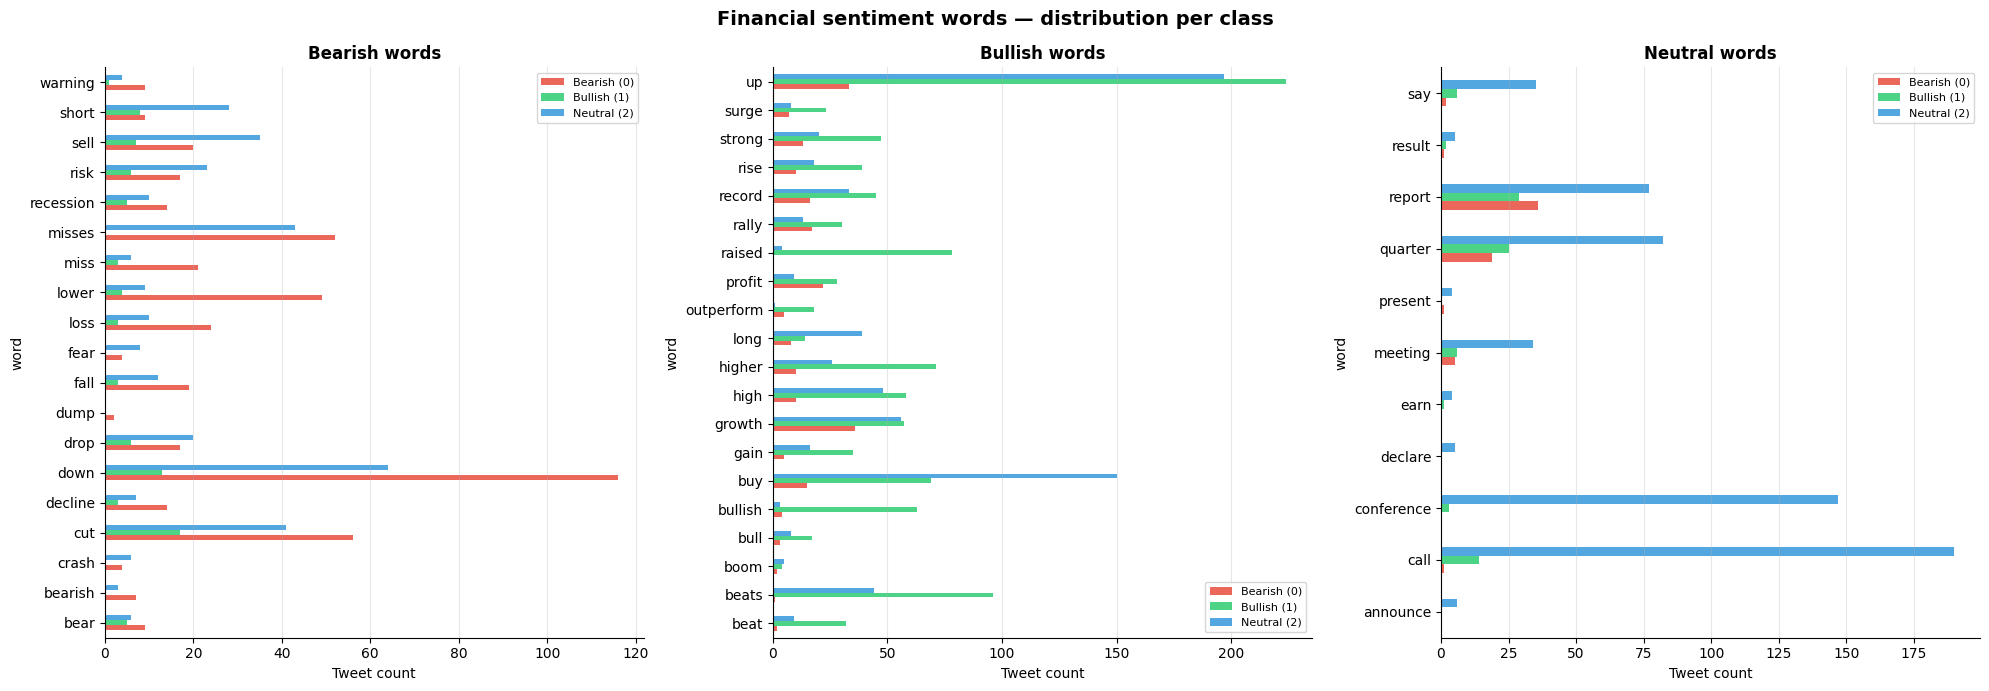

CONCLUSION: Bearish words should dominate class 0, Bullish words class 1.
If confirmed → dataset is coherent and these words will be strong features.


In [10]:
financial_words = {
    'Bearish': ['bear','bearish','crash','dump','fall','drop','loss',
                'decline','miss','misses','cut','lower','down','sell',
                'short','recession','fear','risk','warning'],
    'Bullish': ['bull','bullish','rally','rise','gain','surge','high',
                'beat','beats','raised','higher','buy','long','growth',
                'profit','record','boom','up','strong','outperform'],
    'Neutral': ['report','result','earn','announce','declare','say',
                'conference','meeting','call','present','quarter']
}

results = []
for category, words in financial_words.items():
    for word in words:
        for lbl in [0,1,2]:
            count = df[df['label']==lbl]['text'].str.lower().str.contains(
                rf'\b{word}\b', regex=True).sum()
            results.append({'category':category,'word':word,
                            'class':CLASS_NAMES[lbl],'count':count})
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (category, color) in zip(axes, [('Bearish','#e74c3c'),('Bullish','#2ecc71'),('Neutral','#3498db')]):
    cat_df = res_df[res_df['category']==category]
    pivot  = cat_df.pivot(index='word', columns='class', values='count').fillna(0)
    pivot.plot(kind='barh', ax=ax, color=[CLASS_COLORS[0],CLASS_COLORS[1],CLASS_COLORS[2]],
               edgecolor='none', alpha=0.85)
    ax.set_title(f'{category} words', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tweet count'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False); ax.legend(fontsize=8)
plt.suptitle('Financial sentiment words — distribution per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('CONCLUSION: Bearish words should dominate class 0, Bullish words class 1.')
print('If confirmed → dataset is coherent and these words will be strong features.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-7'></a>
### 2.7 N-gram Analysis (Bigrams & Trigrams)

Bigrams like *"beats earnings"* (Bullish) or *"misses estimates"* (Bearish) are not captured by unigrams alone. This analysis directly informs the `ngram_range` parameter in TF-IDF.

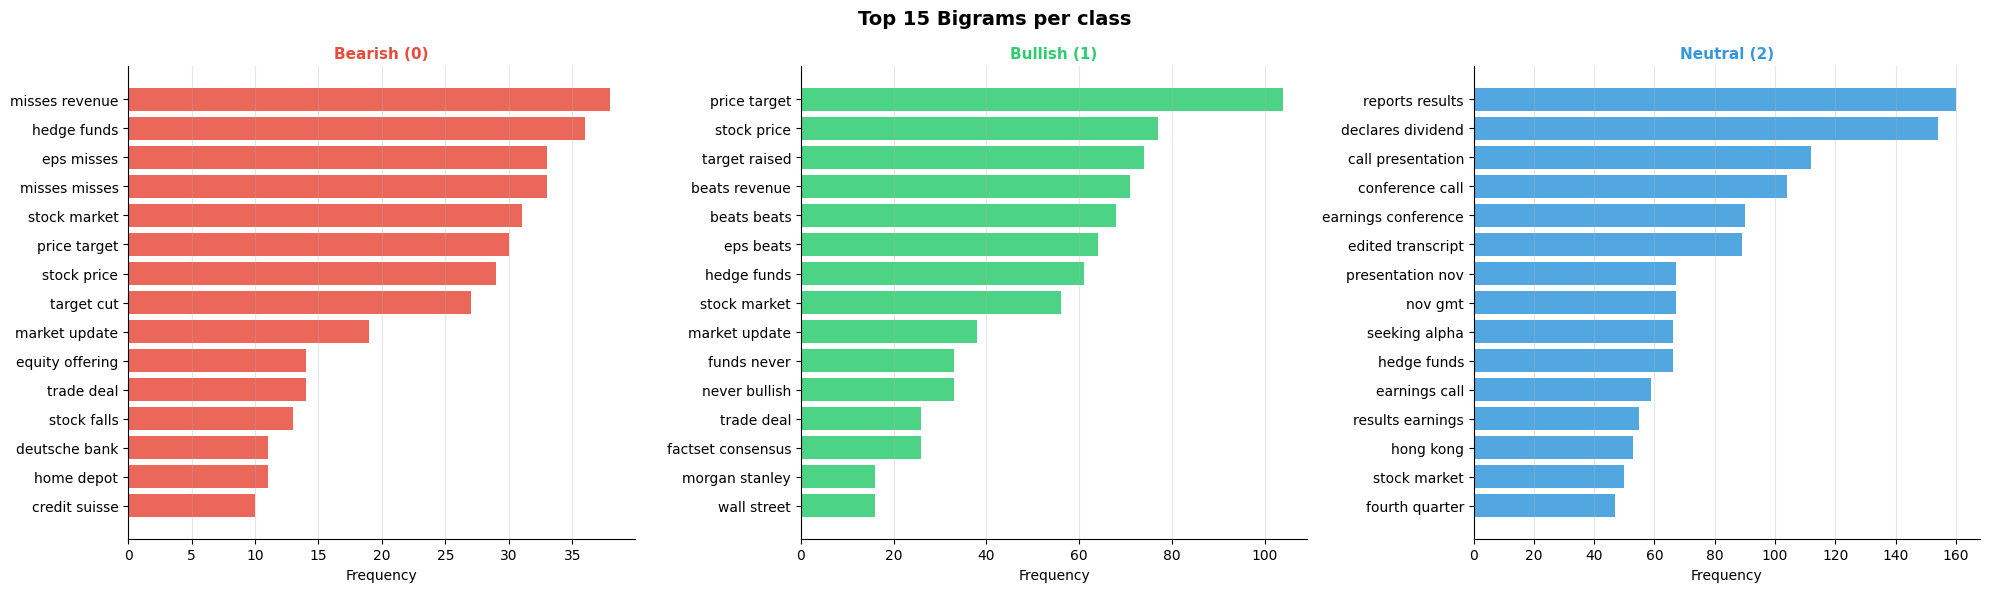

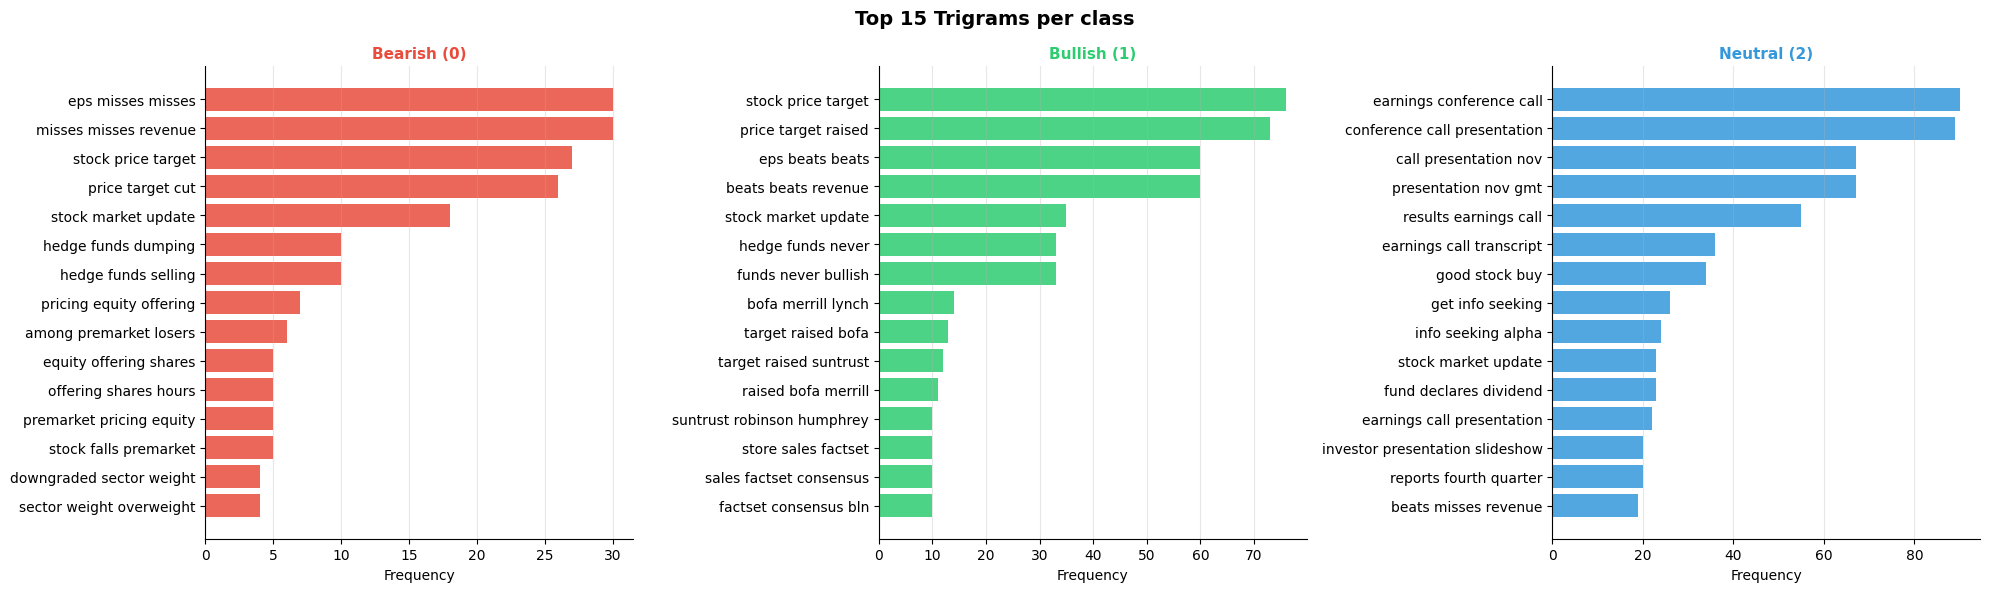

CONCLUSION: If bigrams like "beats earnings" appear in Bullish → use ngram_range=(1,2) in TF-IDF.


In [11]:
def get_ngrams(texts, n):
    all_ng = []
    for text in texts:
        tokens = tokenize_explore(text)
        all_ng.extend([' '.join(g) for g in ngrams(tokens, n)])
    return Counter(all_ng)

for n, label_n in [(2,'Bigrams'),(3,'Trigrams')]:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for lbl, ax in zip([0,1,2], axes):
        ng  = get_ngrams(df[df['label']==lbl]['text'], n)
        top = ng.most_common(15)
        if top:
            words, counts = zip(*top)
            ax.barh(list(reversed(words)), list(reversed(counts)),
                    color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
        ax.set_title(CLASS_NAMES[lbl], fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
        ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    plt.suptitle(f'Top 15 {label_n} per class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
print('CONCLUSION: If bigrams like "beats earnings" appear in Bullish → use ngram_range=(1,2) in TF-IDF.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-8'></a>
### 2.8 Special Features (Hashtags, Mentions, URLs, Numbers)

=== Average presence per tweet ===
  n_hashtags     : 0.23 (max: 7)
  n_mentions     : 0.04 (max: 8)
  n_urls         : 0.53 (max: 3)
  n_numbers      : 0.50 (max: 12)
  Tweets with cashtag: 1,429 (15.0%)

=== Average per class ===
             n_hashtags  n_mentions  n_urls  n_numbers
Bearish (0)        0.17        0.02    0.51       0.53
Bullish (1)        0.16        0.02    0.44       0.74
Neutral (2)        0.27        0.05    0.57       0.42


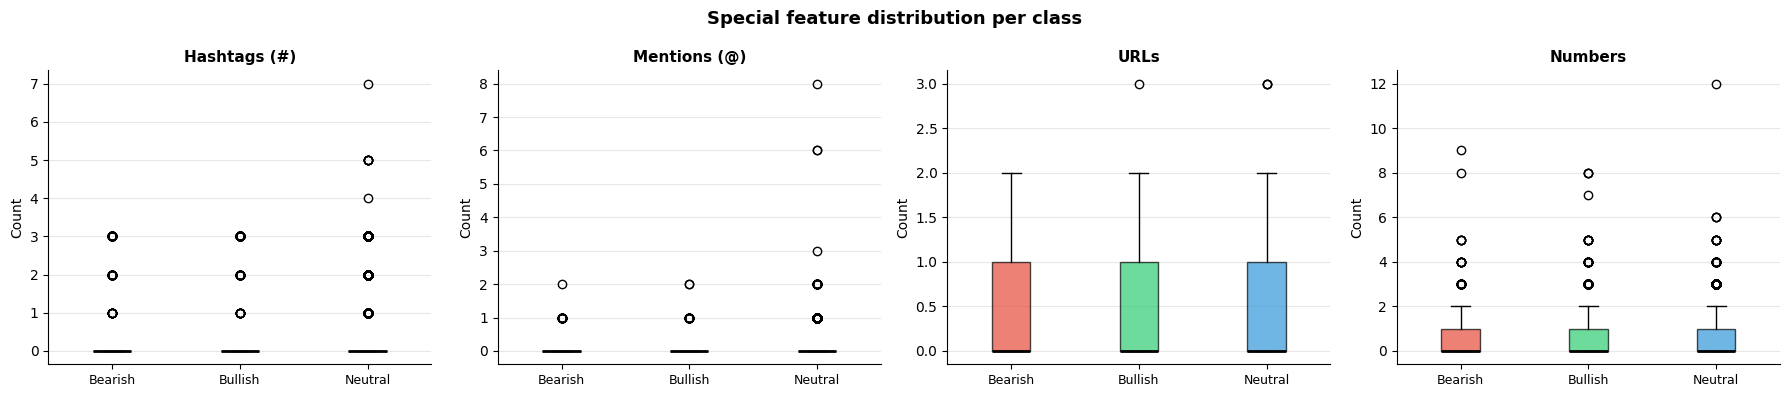

In [12]:
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))

print('=== Average presence per tweet ===')
for feat in ['n_hashtags','n_mentions','n_urls','n_numbers']:
    print(f'  {feat:<15}: {df[feat].mean():.2f} (max: {df[feat].max()})')
print(f'  Tweets with cashtag: {df["has_cashtag"].sum():,} ({df["has_cashtag"].mean()*100:.1f}%)')
print('\n=== Average per class ===')
feat_by_class = df.groupby('label')[['n_hashtags','n_mentions','n_urls','n_numbers']].mean().round(2)
feat_by_class.index = [CLASS_NAMES[i] for i in feat_by_class.index]
print(feat_by_class)

features    = ['n_hashtags','n_mentions','n_urls','n_numbers']
feat_labels = ['Hashtags (#)','Mentions (@)','URLs','Numbers']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for feat, flabel, ax in zip(features, feat_labels, axes):
    data = [df[df['label']==lbl][feat].values for lbl in [0,1,2]]
    bp = ax.boxplot(data, patch_artist=True, medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl]); patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish','Bullish','Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Special feature distribution per class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-9'></a>
### 2.9 Top Hashtags & Cashtags per Class

If the same tickers appear across all classes → normalise to `TICKER`. If some are exclusive to one class → they may be useful features.

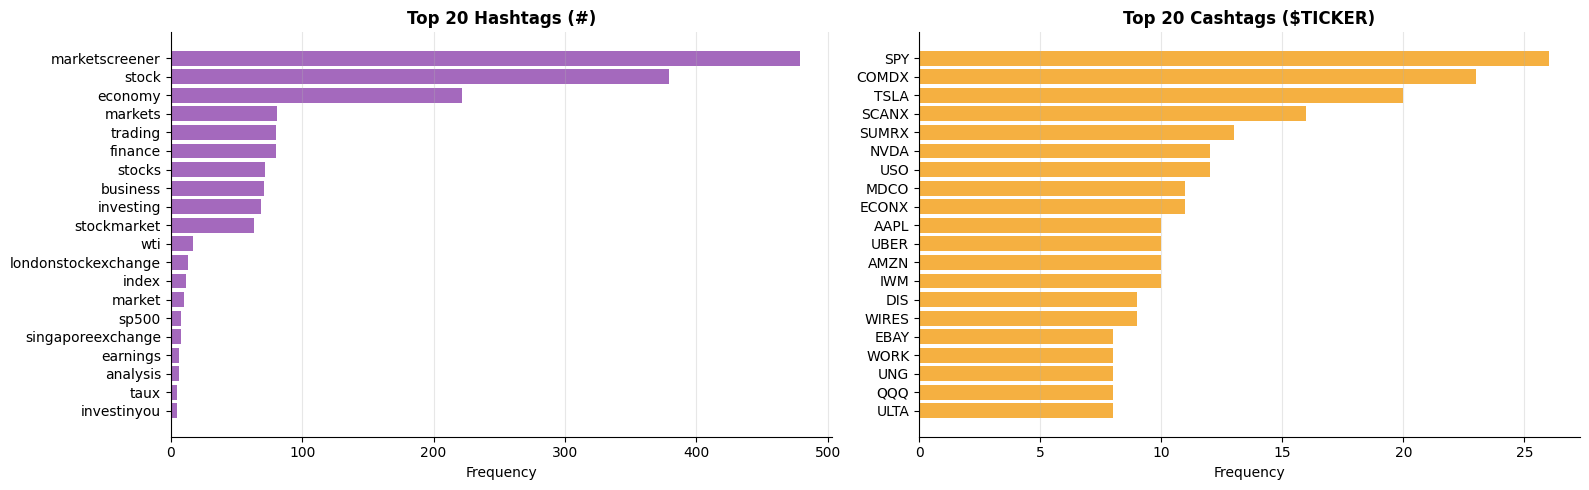

In [13]:
all_hashtags = []
for txt in df['text']:
    all_hashtags.extend(re.findall(r'#(\w+)', str(txt).lower()))
top_hashtags = Counter(all_hashtags).most_common(20)

all_cashtags_raw = []
for txt in df['text']:
    all_cashtags_raw.extend(re.findall(r'\$([A-Za-z]{1,5})', str(txt).upper()))
top_cashtags = Counter(all_cashtags_raw).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if top_hashtags:
    wh, ch = zip(*top_hashtags)
    axes[0].barh(list(reversed(wh)), list(reversed(ch)),
                 color='#8e44ad', edgecolor='none', alpha=0.8)
    axes[0].set_title('Top 20 Hashtags (#)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frequency'); axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)
if top_cashtags:
    wc, cc = zip(*top_cashtags)
    axes[1].barh(list(reversed(wc)), list(reversed(cc)),
                 color='#f39c12', edgecolor='none', alpha=0.8)
    axes[1].set_title('Top 20 Cashtags ($TICKER)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequency'); axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
# ── Cashtags per class — are they discriminative? ────────────────────────────
cashtags_per_class = {}
for lbl in [0,1,2]:
    subset   = df[df['label']==lbl]['text']
    all_cash = []
    for txt in subset:
        all_cash.extend(re.findall(r'\$([A-Za-z]{1,5})', str(txt).upper()))
    cashtags_per_class[lbl] = set(all_cash)

comuns = cashtags_per_class[0] & cashtags_per_class[1] & cashtags_per_class[2]
print(f'Cashtags common to all 3 classes (low discriminative power): {len(comuns)}')
print(f'Examples: {list(comuns)[:10]}')
print()
for lbl in [0,1,2]:
    others    = set().union(*[cashtags_per_class[l] for l in [0,1,2] if l!=lbl])
    exclusive = cashtags_per_class[lbl] - others
    print(f'{CLASS_NAMES[lbl]}: {len(exclusive)} exclusive cashtags → {list(exclusive)[:8]}')
print()
print('CONCLUSION: If most tickers are shared → substitute all with TICKER in preprocessing.')
print('If there are exclusive tickers per class → consider keeping the most frequent ones.')

Cashtags common to all 3 classes (low discriminative power): 34
Examples: ['XOM', 'SPY', 'MDCO', 'FL', 'ECONX', 'IQ', 'SCANX', 'F', 'AMZN', 'UBER']

Bearish (0): 141 exclusive cashtags → ['FFIN', 'VNQ', 'GBX', 'PCYG', 'TME', 'IBN', 'XERS', 'BZUN']
Bullish (1): 279 exclusive cashtags → ['TENB', 'WTS', 'ENI', 'EYPT', 'KLAC', 'LIVX', 'ON', 'PLSQF']
Neutral (2): 562 exclusive cashtags → ['FRTA', 'BXMT', 'ELTP', 'LEAF', 'TXN', 'BITA', 'ELY', 'BNKXY']

CONCLUSION: If most tickers are shared → substitute all with TICKER in preprocessing.
If there are exclusive tickers per class → consider keeping the most frequent ones.


[↑ Back to TOC](#toc)

<a class='anchor' id='2-10'></a>
### 2.10 Tweets with Little Content After Cleaning

Tweets that become empty or have fewer than 3 tokens after cleaning are problematic for models — important to identify them now.

Empty tweets after cleaning (0 tokens): 10
Tweets with fewer than 3 tokens:        156
Tweets with useful content (≥3 tokens): 9,387


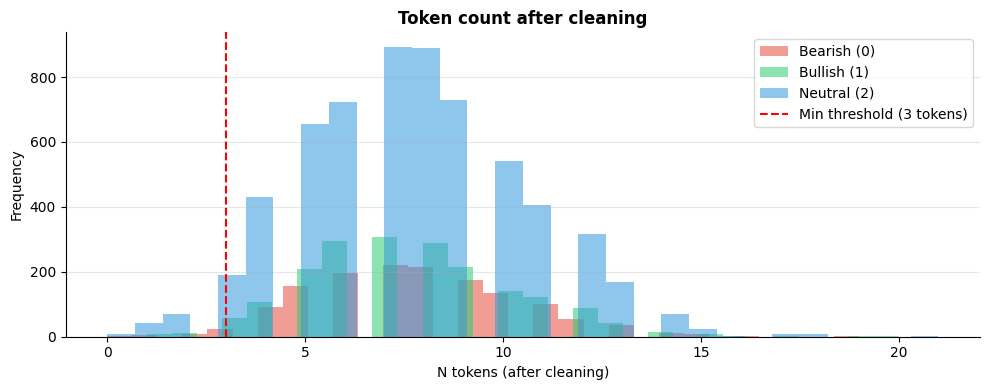


Sample of short/empty tweets:
                                                                                                                        text  label  n_tokens_clean
6                                                                              $GM - GM loses a bull https://t.co/tdUfG5HbXy      0               2
654                                        QE Infinity: So It Begins. https://t.co/HppY8KK3fV #business #stocks #stockmarket      2               2
1119                                                                        $LK calls @BlackBox_Team https://t.co/f0cvVLxwvW      2               1
1192                     AbbVie : Form 8.3 -  #AbbVie #Stock #MarketScreener https://t.co/QPZhKPWGjF https://t.co/AS7H0SkVG8      2               2
1612  JEOL : Form 8.3 - https://t.co/erBSsYuL00 #JEOL #Stock #MarketScreener https://t.co/Lt8CXiXJDy https://t.co/yVehgWa695      2               2
1692                     MongoDB : Form 10-Q #MongoDB #Stock #MarketScreener http

In [15]:
df['tokens_clean']   = df['text'].apply(tokenize_explore)
df['n_tokens_clean'] = df['tokens_clean'].str.len()

empty        = (df['n_tokens_clean'] == 0).sum()
short_tweets = (df['n_tokens_clean'] < 3).sum()

print(f'Empty tweets after cleaning (0 tokens): {empty}')
print(f'Tweets with fewer than 3 tokens:        {short_tweets}')
print(f'Tweets with useful content (≥3 tokens): {(df["n_tokens_clean"] >= 3).sum():,}')

fig, ax = plt.subplots(figsize=(10, 4))
for lbl in [0,1,2]:
    ax.hist(df[df['label']==lbl]['n_tokens_clean'], bins=30, alpha=0.55,
            color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Min threshold (3 tokens)')
ax.set_title('Token count after cleaning', fontsize=12, fontweight='bold')
ax.set_xlabel('N tokens (after cleaning)'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

if short_tweets > 0:
    mask = df['n_tokens_clean'] < 3
    print('\nSample of short/empty tweets:')
    print(df[mask][['text','label','n_tokens_clean']].head(10).to_string())

[↑ Back to TOC](#toc)

<a class='anchor' id='2-11'></a>
### 2.11 Exclusive Vocabulary per Class

Words that appear in **only one class** are the most discriminative features — directly justifies using TF-IDF with high `max_features`.

=== Exclusive vocabulary per class (top 20) ===

Bearish (0) — 955 exclusive words:
  plunges                   9
  sinks                     8
  tumble                    8
  downgrade                 7
  tumbles                   6
  headwinds                 6
  cymabay                   5
  tumbled                   5
  gamestop                  5
  cashing                   4
  sliding                   4
  lakewood                  4
  hitting                   4
  recalls                   4
  laundering                4
  underperform              4
  slashed                   4
  plummets                  4
  slash                     3
  vulnerable                3

Bullish (1) — 1165 exclusive words:
  climbs                   11
  jumped                    8
  levi                      6
  inpx                      6
  bounces                   5
  hasbro                    5
  intercept                 5
  icpt                      5
  ounce                     5
  ions   

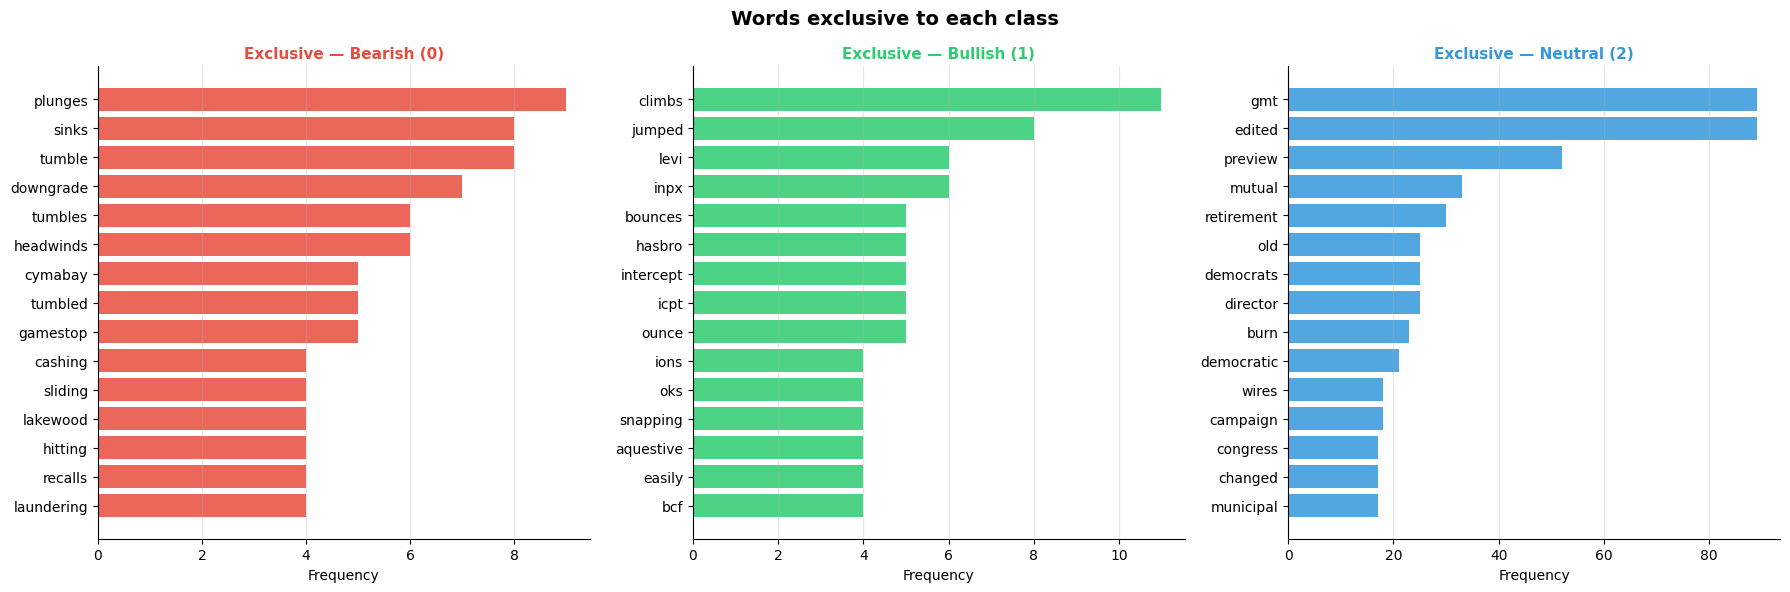

In [16]:
vocab_per_class = {}
freq_per_class  = {}
for lbl in [0,1,2]:
    toks = []
    for txt in df[df['label']==lbl]['text']:
        toks.extend(tokenize_explore(txt))
    vocab_per_class[lbl] = set(toks)
    freq_per_class[lbl]  = Counter(toks)

print('=== Exclusive vocabulary per class (top 20) ===')
for lbl in [0,1,2]:
    others    = set().union(*[vocab_per_class[l] for l in [0,1,2] if l!=lbl])
    exclusive = vocab_per_class[lbl] - others
    top_excl  = sorted(exclusive, key=lambda w: freq_per_class[lbl][w], reverse=True)[:20]
    print(f'\n{CLASS_NAMES[lbl]} — {len(exclusive)} exclusive words:')
    for w in top_excl:
        print(f'  {w:<22} {freq_per_class[lbl][w]:>4}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0,1,2], axes):
    others    = set().union(*[vocab_per_class[l] for l in [0,1,2] if l!=lbl])
    exclusive = vocab_per_class[lbl] - others
    top_excl  = sorted(exclusive, key=lambda w: freq_per_class[lbl][w], reverse=True)[:15]
    counts    = [freq_per_class[lbl][w] for w in top_excl]
    ax.barh(list(reversed(top_excl)), list(reversed(counts)),
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Exclusive — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Words exclusive to each class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-12'></a>
### 2.12 Lexical Dispersion

A word that appears 500 times but only in 3 tweets is not a good feature (likely noise). This justifies the `min_df` parameter in TF-IDF.

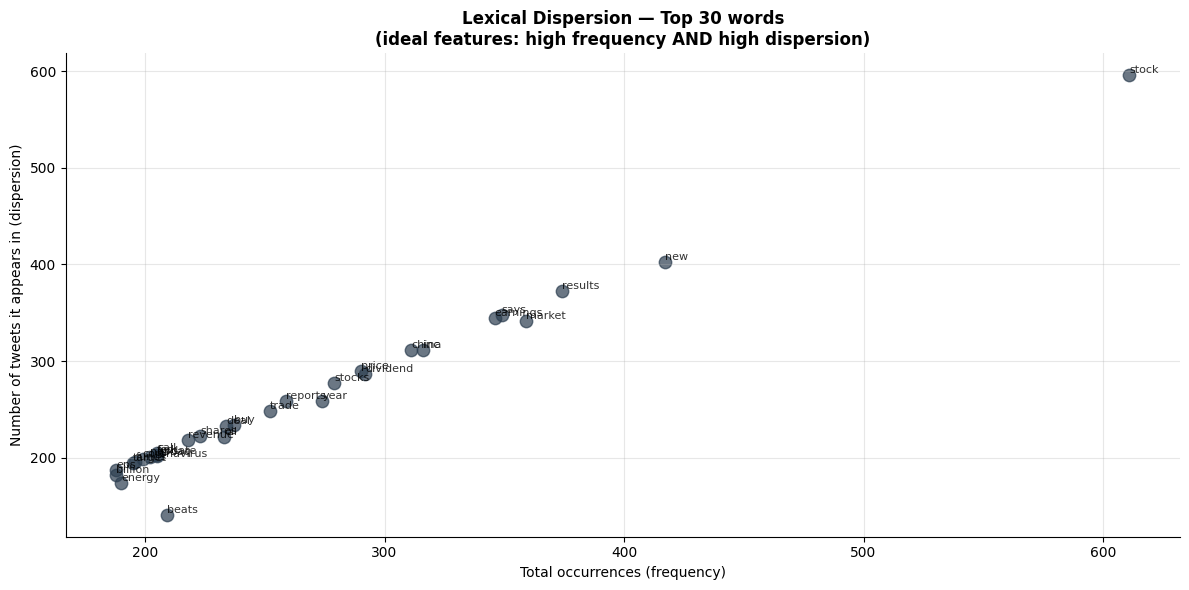

CONCLUSION: Words concentrated in few tweets → set min_df=2 or min_df=3 in TF-IDF/BoW.


In [17]:
word_doc_count = defaultdict(int)
word_total     = Counter()

for text in df['text']:
    tokens_set = set(tokenize_explore(text))
    for t in tokens_set:
        word_doc_count[t] += 1

for text in df['text']:
    word_total.update(tokenize_explore(text))

top30 = [w for w, _ in word_total.most_common(30)]
x_vals = [word_total[w]    for w in top30]
y_vals = [word_doc_count[w] for w in top30]

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(x_vals, y_vals, c='#2c3e50', alpha=0.7, s=80)
for i, word in enumerate(top30):
    ax.annotate(word, (x_vals[i], y_vals[i]),
                fontsize=8, ha='left', va='bottom', alpha=0.8)
ax.set_xlabel('Total occurrences (frequency)')
ax.set_ylabel('Number of tweets it appears in (dispersion)')
ax.set_title('Lexical Dispersion — Top 30 words\n(ideal features: high frequency AND high dispersion)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('CONCLUSION: Words concentrated in few tweets → set min_df=2 or min_df=3 in TF-IDF/BoW.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-13'></a>
### 2.13 Co-occurrence Heatmap

Top words that frequently appear together — supports the use of bigrams in TF-IDF.

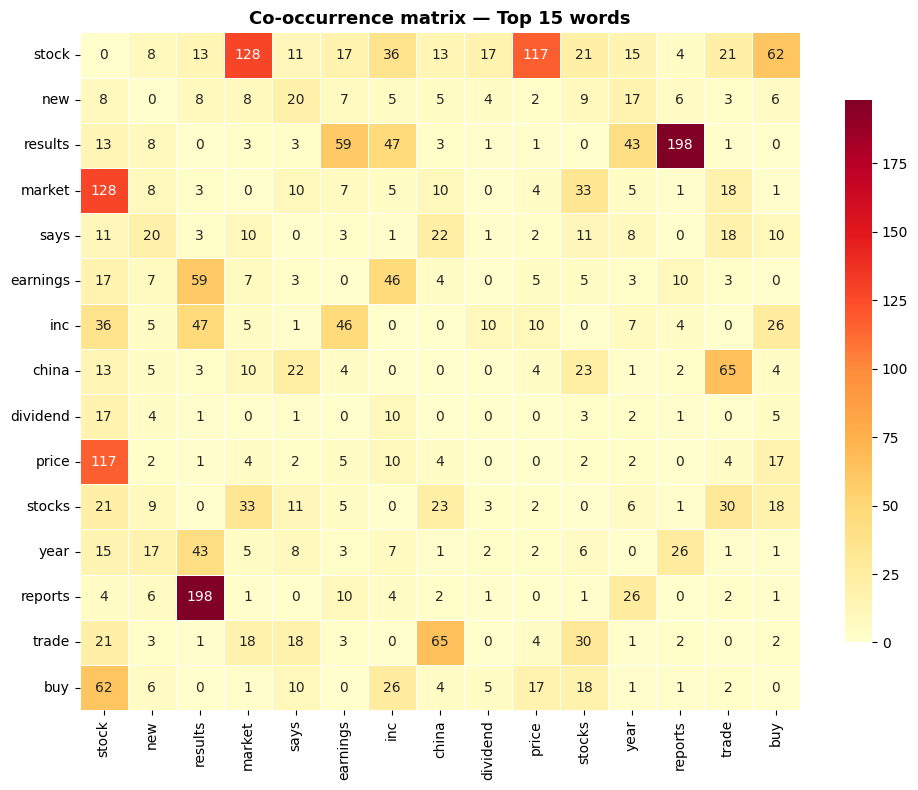

High co-occurrence pairs → strong bigram candidates for TF-IDF ngram_range=(1,2).


In [18]:
top_words_list = [w for w, _ in freq.most_common(15)]
cooc = pd.DataFrame(0, index=top_words_list, columns=top_words_list)

for txt in df['text']:
    tokens = set(tokenize_explore(txt)) & set(top_words_list)
    for w1, w2 in combinations(tokens, 2):
        cooc.loc[w1,w2] += 1
        cooc.loc[w2,w1] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Co-occurrence matrix — Top 15 words', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('High co-occurrence pairs → strong bigram candidates for TF-IDF ngram_range=(1,2).')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-14'></a>
### 2.14 Tweet Length Boxplot & Statistical Test

If tweet length differs significantly between classes (Kruskal-Wallis p < 0.05), `n_words` can be used as an extra feature.

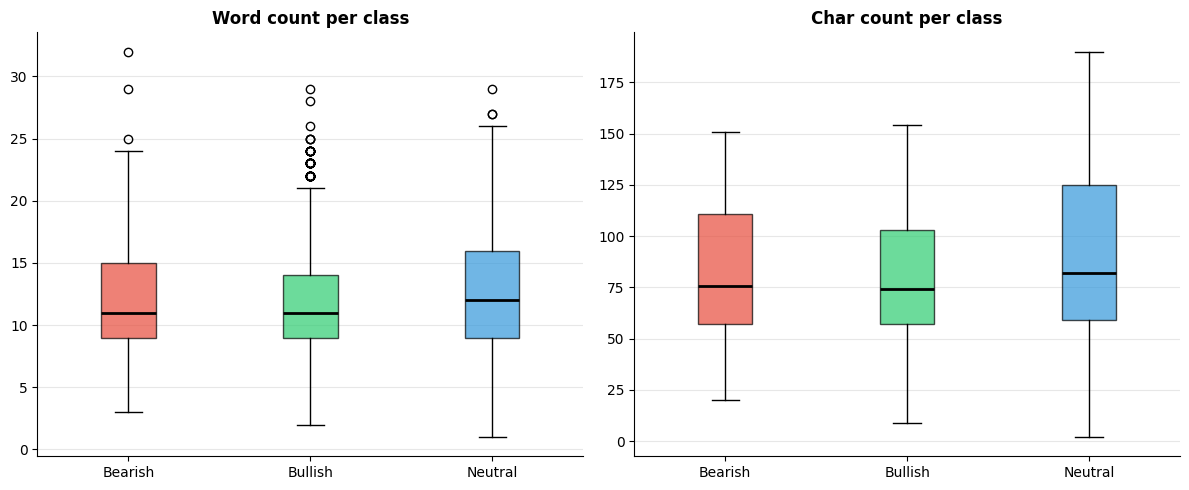

Kruskal-Wallis test (tweet length difference between classes):
  statistic = 8.97   p-value = 0.0113
  → Statistically significant! Tweet length can be used as an extra feature.

Mean word count per class:
label
Bearish (0)    12.0
Bullish (1)    11.9
Neutral (2)    12.3
Name: n_words, dtype: float64


In [19]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for metric, ax, title in [('n_words',axes[0],'Word count per class'),
                            ('n_chars', axes[1],'Char count per class')]:
    data = [df[df['label']==lbl][metric].values for lbl in [0,1,2]]
    bp   = ax.boxplot(data, patch_artist=True, medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'],[0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl]); patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish','Bullish','Neutral'], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

bear = df[df['label']==0]['n_words']
bull = df[df['label']==1]['n_words']
neut = df[df['label']==2]['n_words']
stat, p = stats.kruskal(bear, bull, neut)
print(f'Kruskal-Wallis test (tweet length difference between classes):')
print(f'  statistic = {stat:.2f}   p-value = {p:.4f}')
if p < 0.05:
    print('  → Statistically significant! Tweet length can be used as an extra feature.')
else:
    print('  → No significant difference. Length does not discriminate classes well.')
print('\nMean word count per class:')
print(df.groupby('label')['n_words'].mean().round(1).rename(index=CLASS_NAMES))

[↑ Back to TOC](#toc)

<a class='anchor' id='2-15'></a>
### 2.15 Exploration Summary & Conclusions

In [20]:
print('=' * 65)
print('DATA EXPLORATION SUMMARY')
print('=' * 65)
print(f'Total tweets (train):            {len(df):,}')
print(f'Unique vocabulary (no stopwords):{len(vocab):,} words')
print(f'Total tokens:                    {len(all_tokens):,}')
print(f'Avg tweet length:                {df["n_words"].mean():.1f} words / {df["n_chars"].mean():.0f} chars')
print()
print('Class distribution:')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print(f'Majority-class baseline: {majority_acc:.1f}%')
print()
print('Key findings:')
print('  1. Class imbalance is moderate → use class_weight="balanced"')
print('  2. Financial keywords appear in expected classes → coherent dataset')
print('  3. Bigrams are informative → use ngram_range=(1,2) in TF-IDF')
print('  4. Most cashtags appear across all classes → normalise to TICKER')
print('  5. Lexical dispersion confirms that min_df=2 in TF-IDF is appropriate')
print('=' * 65)

DATA EXPLORATION SUMMARY
Total tweets (train):            9,543
Unique vocabulary (no stopwords):14,016 words
Total tokens:                    73,385
Avg tweet length:                12.2 words / 86 chars

Class distribution:
  Bearish (0): 1,442 (15.1%)
  Bullish (1): 1,923 (20.2%)
  Neutral (2): 6,178 (64.7%)

Majority-class baseline: 64.7%

Key findings:
  1. Class imbalance is moderate → use class_weight="balanced"
  2. Financial keywords appear in expected classes → coherent dataset
  3. Bigrams are informative → use ngram_range=(1,2) in TF-IDF
  4. Most cashtags appear across all classes → normalise to TICKER
  5. Lexical dispersion confirms that min_df=2 in TF-IDF is appropriate


[↑ Back to TOC](#toc)

<a class='anchor' id='3'></a>
---
## 3. Data Preprocessing

Two separate preprocessing pipelines are used:
- **Classical pipeline** (BoW / TF-IDF / Word2Vec + Traditional ML): full cleaning with lemmatization.
- **Transformer pipeline** (BERT / FinBERT / RoBERTa): minimal cleaning only — the tokenizer handles the rest.

**Techniques applied (≥4 required):** Lowercasing · URL removal · @mention removal · Hashtag normalisation · Cashtag normalisation · Non-alpha regex · Stopword removal · Lemmatization · `word_tokenize`

<a class='anchor' id='3-1'></a>
### 3.1 Step-by-step Demonstration

In [21]:
tweet_example = "$TSLA beats earnings! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%"
t = tweet_example
steps = [
    ('1. Original',             t),
    ('2. Lowercase',            t := t.lower()),
    ('3. Remove URLs',          t := re.sub(r'http\S+|www\S+','',t)),
    ('4. Remove @mentions',     t := re.sub(r'@\w+','',t)),
    ('5. Hashtags → words',     t := re.sub(r'#(\w+)',r'\1',t)),
    ('6. Cashtags → ticker',    t := re.sub(r'\$[a-zA-Z]{1,5}','ticker',t)),
    ('7. Letters only (regex)', t := re.sub(r'[^a-zA-Z\s]',' ',t)),
    ('8. Remove stopwords',     t := ' '.join(w for w in t.split() if w not in STOP and len(w)>2)),
    ('9. Lemmatization',        t := ' '.join(lemma.lemmatize(w) for w in t.split())),
]
print('='*70)
for step_name, step_text in steps:
    print(f'{step_name:<30} → {step_text.strip()}')
print('='*70)

1. Original                    → $TSLA beats earnings! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
2. Lowercase                   → $tsla beats earnings! #bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
3. Remove URLs                 → $tsla beats earnings! #bullish #stocks @elonmusk  up 5.3%
4. Remove @mentions            → $tsla beats earnings! #bullish #stocks   up 5.3%
5. Hashtags → words            → $tsla beats earnings! bullish stocks   up 5.3%
6. Cashtags → ticker           → ticker beats earnings! bullish stocks   up 5.3%
7. Letters only (regex)        → ticker beats earnings  bullish stocks   up
8. Remove stopwords            → ticker beats earnings bullish stocks
9. Lemmatization               → ticker beat earnings bullish stock


[↑ Back to TOC](#toc)

<a class='anchor' id='3-2'></a>
### 3.2 Lemmatization vs Stemming

Lemmatization is chosen: it preserves recognisable word forms, crucial for financial text (e.g. *"bullish"* should not become *"bulli"*).

In [22]:
financial_words_cmp = [
    'beats','beating','beaten','misses','missing','missed',
    'earnings','earning','rises','rising','raised',
    'falling','fallen','falls','bullish','bearish','investing','investors',
]
print(f"{'Word':<18} {'Lemma':<18} {'Stem':<18} Notes")
print('-'*70)
for word in financial_words_cmp:
    l = lemma.lemmatize(word)
    s = stemmer.stem(word)
    note = '← different!' if l != s else ''
    print(f'{word:<18} {l:<18} {s:<18} {note}')
print('\nDecision: Lemmatization used in the classical pipeline (use_lemma=True).')

Word               Lemma              Stem               Notes
----------------------------------------------------------------------
beats              beat               beat               
beating            beating            beat               ← different!
beaten             beaten             beaten             
misses             miss               miss               
missing            missing            miss               ← different!
missed             missed             miss               ← different!
earnings           earnings           earn               ← different!
earning            earning            earn               ← different!
rises              rise               rise               
rising             rising             rise               ← different!
raised             raised             rais               ← different!
falling            falling            fall               ← different!
fallen             fallen             fallen             
falls           

[↑ Back to TOC](#toc)

<a class='anchor' id='3-3'></a>
### 3.3 Preprocessing Functions

In [23]:
from tqdm import tqdm

def preprocess_classical(text_list, use_lemma=True, use_stemmer=False):
    """
    Full text cleaning for classical ML models (BoW / TF-IDF / Word2Vec).
    Steps: lowercase → URLs → @mentions → hashtags → cashtags
           → regex (non-alpha) → stopwords → word_tokenize → lemmatize.
    """
    results = []
    for text in tqdm(text_list, desc='Classical preprocessing'):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#(\w+)', r'\1', text)
        text = re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        tokens = word_tokenize(text)
        tokens = [w for w in tokens if w not in STOP and len(w) > 2]
        if use_lemma:    tokens = [lemma.lemmatize(w) for w in tokens]
        if use_stemmer:  tokens = [stemmer.stem(w) for w in tokens]
        results.append(' '.join(tokens))
    return results


def preprocess_transformer(text_list):
    """
    Minimal cleaning for Transformer models (BERT / FinBERT / RoBERTa).
    The model tokenizer handles sub-word splitting; heavy cleaning hurts performance.
    Steps: remove URLs → normalise whitespace.
    """
    results = []
    for text in tqdm(text_list, desc='Transformer preprocessing'):
        text = str(text)
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        results.append(text)
    return results

print('✅ preprocess_classical() and preprocess_transformer() defined.')

✅ preprocess_classical() and preprocess_transformer() defined.


[↑ Back to TOC](#toc)

<a class='anchor' id='3-4'></a>
### 3.4 Apply to Full Training Set

> **Note on leakage:** `preprocess_classical` and `preprocess_transformer` are deterministic — they learn nothing from the data. They can safely be applied to the full dataset before the CV split. The only operations that must be fitted exclusively on the train fold are vectorisers (TF-IDF, Word2Vec) — these are handled inside `Pipeline` objects in Section 6.

In [24]:
print('Applying classical pipeline (lemmatization)...')
df['text_lemma'] = preprocess_classical(df['text'].tolist(), use_lemma=True, use_stemmer=False)

print('Applying classical pipeline (stemming — for comparison)...')
df['text_stem']  = preprocess_classical(df['text'].tolist(), use_lemma=False, use_stemmer=True)

print('Applying transformer pipeline...')
df['text_transformer'] = preprocess_transformer(df['text'].tolist())

print('\n✅ Preprocessing complete!')
print(f'Columns available: {list(df.columns)}')

Applying classical pipeline (lemmatization)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:01<00:00, 9221.56it/s]


Applying classical pipeline (stemming — for comparison)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:01<00:00, 8079.09it/s]


Applying transformer pipeline...


Transformer preprocessing: 100%|██████████| 9543/9543 [00:00<00:00, 156592.91it/s]


✅ Preprocessing complete!
Columns available: ['text', 'label', 'n_chars', 'n_words', 'n_tokens', 'n_hashtags', 'n_mentions', 'n_urls', 'n_numbers', 'has_cashtag', 'tokens_clean', 'n_tokens_clean', 'text_lemma', 'text_stem', 'text_transformer']


[↑ Back to TOC](#toc)

<a class='anchor' id='3-5'></a>
### 3.5 Before / After Comparison

In [25]:
print('Before / after preprocessing — 5 examples:\n')
for i in range(5):
    print(f'[{i}] ORIGINAL    : {df["text"].iloc[i]}')
    print(f'    LEMMA       : {df["text_lemma"].iloc[i]}')
    print(f'    STEM        : {df["text_stem"].iloc[i]}')
    print(f'    TRANSFORMER : {df["text_transformer"].iloc[i]}')
    print()

Before / after preprocessing — 5 examples:

[0] ORIGINAL    : $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
    LEMMA       : ticker jpmorgan reel expectation beyond meat
    STEM        : ticker jpmorgan reel expect beyond meat
    TRANSFORMER : $BYND - JPMorgan reels in expectations on Beyond Meat

[1] ORIGINAL    : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
    LEMMA       : ticker ticker nomura point booking weakness carnival royal caribbean
    STEM        : ticker ticker nomura point book weak carniv royal caribbean
    TRANSFORMER : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean

[2] ORIGINAL    : $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
    LEMMA       : ticker cemex cut credit suisse morgan weak building outlook
    STEM        : ticker cemex cut credit suiss morgan weak build outlook
    TRANSFORMER :

[↑ Back to TOC](#toc)

<a class='anchor' id='3-6'></a>
### 3.6 Vocabulary Impact

In [26]:
def get_vocab(series):
    tokens = []
    for text in series: tokens.extend(str(text).split())
    return set(tokens), len(tokens)

v_orig,  t_orig  = get_vocab(df['text'])
v_lemma, t_lemma = get_vocab(df['text_lemma'])
v_stem,  t_stem  = get_vocab(df['text_stem'])

print(f"{'Version':<20} {'Total tokens':>15} {'Unique vocab':>15}")
print('-'*52)
print(f"{'Original':<20} {t_orig:>15,} {len(v_orig):>15,}")
print(f"{'Lemmatization':<20} {t_lemma:>15,} {len(v_lemma):>15,}")
print(f"{'Stemming':<20} {t_stem:>15,} {len(v_stem):>15,}")
print()
print(f'Vocab reduction (lemma vs original): {(1-len(v_lemma)/len(v_orig))*100:.1f}%')
print(f'Vocab reduction (stem  vs original): {(1-len(v_stem)/len(v_orig))*100:.1f}%')

Version                 Total tokens    Unique vocab
----------------------------------------------------
Original                     116,218          31,609
Lemmatization                 75,721          12,374
Stemming                      75,721          10,406

Vocab reduction (lemma vs original): 60.9%
Vocab reduction (stem  vs original): 67.1%


[↑ Back to TOC](#toc)

<a class='anchor' id='3-7'></a>
### 3.7 Empty Tweets After Cleaning

In [27]:
empty_lemma = (df['text_lemma'].str.strip() == '').sum()
short_lemma = (df['text_lemma'].str.split().str.len() < 3).sum()
print(f'Empty tweets after cleaning: {empty_lemma}')
print(f'Tweets with < 3 words:       {short_lemma}')
if empty_lemma > 0:
    mask = df['text_lemma'].str.strip() == ''
    print('\nOriginal tweets that became empty:')
    print(df[mask][['text','label']].to_string())
    df = df[~mask].reset_index(drop=True)
    print(f'\nDataset after removing empty rows: {len(df)} tweets')
print('\n✅ Preprocessing validation complete.')

Empty tweets after cleaning: 9
Tweets with < 3 words:       147

Original tweets that became empty:
                                                                                                        text  label
3943                                                                                                      :)      2
3948                                                                                                 @TicToc      2
3949                             @tictoc @telefenoticias @teleSUR_Chile @PaoladrateleSUR @monlaferte @inddhh      2
3950  @tictoc @telefenoticias @teleSUR_Chile @PaoladrateleSUR @monlaferte @telefenoticias @inddhh @mbachelet      2
4440                                                                                                      F5      2
4681                                                                                 https://t.co/575AH1YRkF      2
4682                                                                                 htt

[↑ Back to TOC](#toc)

<a class='anchor' id='4'></a>
---
## 4. Corpus Split — Stratified K-Fold

**Stratified K-Fold (k=5)** ensures each fold preserves class proportions.  
Vectoriser / model `.fit()` always happens *inside* each fold via `Pipeline` → no data leakage.

In [28]:
from sklearn.model_selection import StratifiedKFold

X_classical   = df['text_lemma']
X_transformer = df['text_transformer']
y             = df['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Fold distribution (Stratified K-Fold, k=5):')
print(f"{'Fold':<8} {'Train':>8} {'Val':>8} {'Bearish%':>10} {'Bullish%':>10} {'Neutral%':>10}")
print('-'*60)
folds = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_classical, y)):
    y_val_fold = y.iloc[val_idx]
    pcts = y_val_fold.value_counts(normalize=True).sort_index() * 100
    folds.append((train_idx, val_idx))
    print(f"Fold {fold+1:<4} {len(train_idx):>8,} {len(val_idx):>8,} "
          f"{pcts.get(0,0):>9.1f}% {pcts.get(1,0):>9.1f}% {pcts.get(2,0):>9.1f}%")
print()
print('✅ Each fold maintains the same class proportions.')
print('   class_weight="balanced" will be applied in all classical models.')

Fold distribution (Stratified K-Fold, k=5):
Fold        Train      Val   Bearish%   Bullish%   Neutral%
------------------------------------------------------------
Fold 1       7,627    1,907      15.2%      20.1%      64.7%
Fold 2       7,627    1,907      15.1%      20.2%      64.7%
Fold 3       7,627    1,907      15.1%      20.2%      64.7%
Fold 4       7,627    1,907      15.1%      20.2%      64.7%
Fold 5       7,628    1,906      15.1%      20.1%      64.7%

✅ Each fold maintains the same class proportions.
   class_weight="balanced" will be applied in all classical models.


[↑ Back to TOC](#toc)

<a class='anchor' id='5'></a>
---
## 5. Feature Engineering

| Method | Pipeline | Notes |
|---|---|---|
| **BoW / TF-IDF** | Classical | `CountVectorizer` and `TfidfVectorizer` |
| **Word2Vec** | Classical | Gensim; tweet → mean of word vectors |
| **Transformer Encoder** | Transformer | FinBERT, BERT, RoBERTa — [CLS] embeddings |

<a class='anchor' id='5-1'></a>
### 5.1 BoW & TF-IDF

In [29]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Defined here, but always fitted INSIDE a sklearn Pipeline to prevent leakage
bow_vectorizer   = CountVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                    sublinear_tf=True, min_df=2)

print('CountVectorizer (BoW):')
print(f'  max_features={bow_vectorizer.max_features}, ngram_range={bow_vectorizer.ngram_range}')
print('TfidfVectorizer:')
print(f'  max_features={tfidf_vectorizer.max_features}, ngram_range={tfidf_vectorizer.ngram_range}')
print()
print('✅ Vectorisers defined — will be fitted inside Pipelines (no leakage).')

CountVectorizer (BoW):
  max_features=20000, ngram_range=(1, 2)
TfidfVectorizer:
  max_features=20000, ngram_range=(1, 2)

✅ Vectorisers defined — will be fitted inside Pipelines (no leakage).


[↑ Back to TOC](#toc)

<a class='anchor' id='5-2'></a>
### 5.2 Word2Vec — Mean Embedding Transformer

In [30]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MeanWord2VecTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible transformer that:
    1. Trains a Word2Vec model on the input texts (fit).
    2. Converts each text to the mean of its word vectors (transform).
    Fully compatible with cross_val_predict and Pipeline — no leakage.
    """
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=10):
        self.vector_size = vector_size
        self.window      = window
        self.min_count   = min_count
        self.epochs      = epochs

    def fit(self, X, y=None):
        sentences  = [text.split() for text in X]
        self.model = Word2Vec(sentences=sentences, vector_size=self.vector_size,
                              window=self.window, min_count=self.min_count,
                              workers=4, seed=42, epochs=self.epochs)
        return self

    def transform(self, X):
        embeddings = []
        for text in X:
            tokens = [w for w in text.split() if w in self.model.wv]
            if tokens:
                embeddings.append(np.mean(self.model.wv[tokens], axis=0))
            else:
                embeddings.append(np.zeros(self.vector_size))
        return np.array(embeddings)

print('✅ MeanWord2VecTransformer defined — compatible with sklearn Pipeline.')

✅ MeanWord2VecTransformer defined — compatible with sklearn Pipeline.


[↑ Back to TOC](#toc)

<a class='anchor' id='5-3'></a>
### 5.3 Transformer Encoder Embeddings (FinBERT / BERT / RoBERTa)

In [31]:
# pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch

def get_transformer_embeddings(texts, model_name='ProsusAI/finbert',
                                batch_size=32, max_len=128):
    """
    Extracts [CLS] token embeddings from a pre-trained transformer encoder.
    
    Models:
      'ProsusAI/finbert'        — trained on financial text (best fit)
      'bert-base-uncased'       — general BERT baseline
      'distilbert-base-uncased' — lighter, faster BERT  [Extra: +0.50 pts]
      'roberta-base'            — improved BERT          [Extra: +0.50 pts]
    """
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Embedding [{model_name}]'):
        batch   = list(texts[i:i+batch_size])
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt').to(device)
        with torch.no_grad():
            output = model(**encoded)
        cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
    return np.vstack(all_embeddings)

print('✅ get_transformer_embeddings() defined.')
print('   Models: ProsusAI/finbert · bert-base-uncased · roberta-base · distilbert-base-uncased')

✅ get_transformer_embeddings() defined.
   Models: ProsusAI/finbert · bert-base-uncased · roberta-base · distilbert-base-uncased


[↑ Back to TOC](#toc)

<a class='anchor' id='6'></a>
---
## 6. Classification Models

- **Classical ML** uses BoW / TF-IDF / Word2Vec features inside a `Pipeline`.
- **Fine-tuned Transformers** are trained end-to-end.
- All models evaluated with Stratified K-Fold CV.
- `class_weight='balanced'` used throughout.

<a class='anchor' id='6-1'></a>
### 6.1 Evaluation Helper

In [32]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

def evaluate_model(y_true, y_pred, model_name='Model'):
    """Print classification report and plot confusion matrix."""
    print(f'\n=== {model_name} ===')
    print(classification_report(y_true, y_pred,
                                 target_names=['Bearish','Bullish','Neutral']))
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'], ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
    plt.tight_layout(); plt.show()
    return {
        'model':       model_name,
        'accuracy':    accuracy_score(y_true, y_pred),
        'f1_macro':    f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }

results_table = []
print('✅ evaluate_model() defined.')

✅ evaluate_model() defined.


[↑ Back to TOC](#toc)

<a class='anchor' id='6-2'></a>
### 6.2 Traditional ML — TF-IDF / BoW Pipeline

Running CV: LR + TF-IDF...

=== LR + TF-IDF ===
              precision    recall  f1-score   support

     Bearish       0.55      0.63      0.59      1441
     Bullish       0.65      0.72      0.69      1923
     Neutral       0.89      0.83      0.86      6170

    accuracy                           0.78      9534
   macro avg       0.70      0.73      0.71      9534
weighted avg       0.79      0.78      0.78      9534



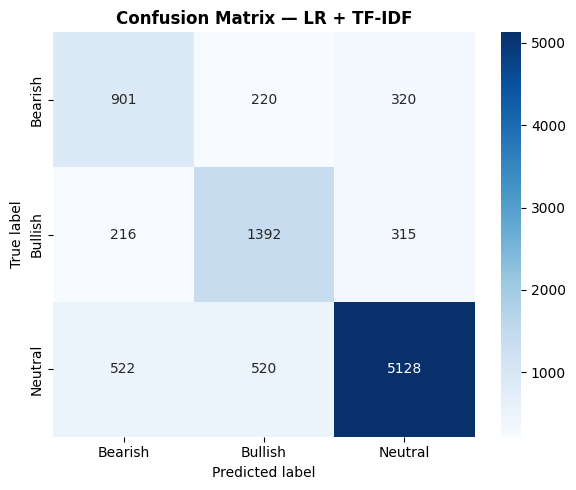

Running CV: XGBoost + TF-IDF...

=== XGBoost + TF-IDF ===
              precision    recall  f1-score   support

     Bearish       0.76      0.36      0.49      1441
     Bullish       0.73      0.52      0.61      1923
     Neutral       0.78      0.95      0.86      6170

    accuracy                           0.77      9534
   macro avg       0.76      0.61      0.65      9534
weighted avg       0.77      0.77      0.75      9534



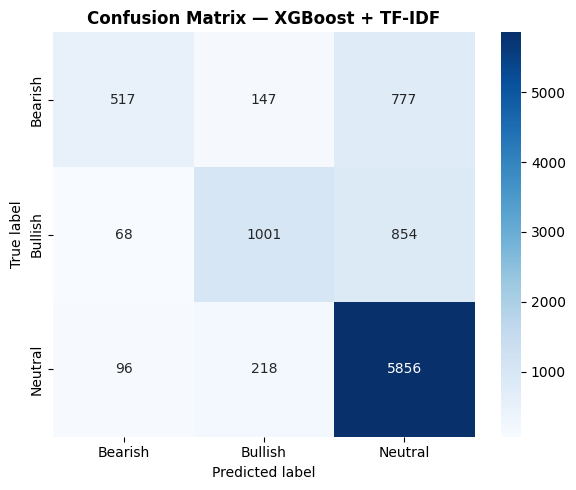

Running CV: MLP + TF-IDF...

=== MLP + TF-IDF ===
              precision    recall  f1-score   support

     Bearish       0.66      0.48      0.56      1441
     Bullish       0.68      0.64      0.66      1923
     Neutral       0.84      0.90      0.87      6170

    accuracy                           0.79      9534
   macro avg       0.72      0.68      0.70      9534
weighted avg       0.78      0.79      0.78      9534



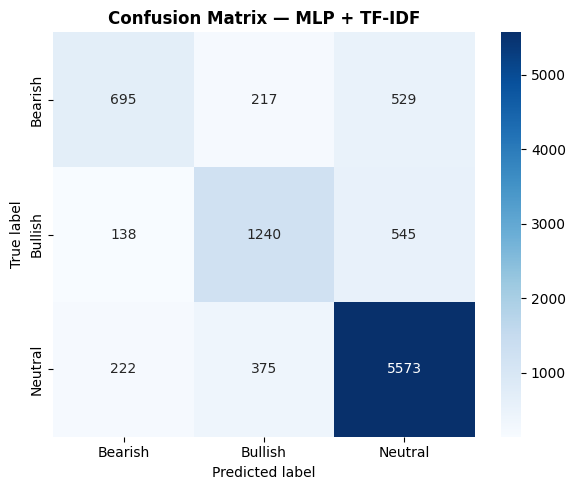

Running CV: RF + BoW...

=== RF + BoW ===
              precision    recall  f1-score   support

     Bearish       0.74      0.40      0.52      1441
     Bullish       0.72      0.60      0.65      1923
     Neutral       0.81      0.94      0.87      6170

    accuracy                           0.79      9534
   macro avg       0.75      0.65      0.68      9534
weighted avg       0.78      0.79      0.77      9534



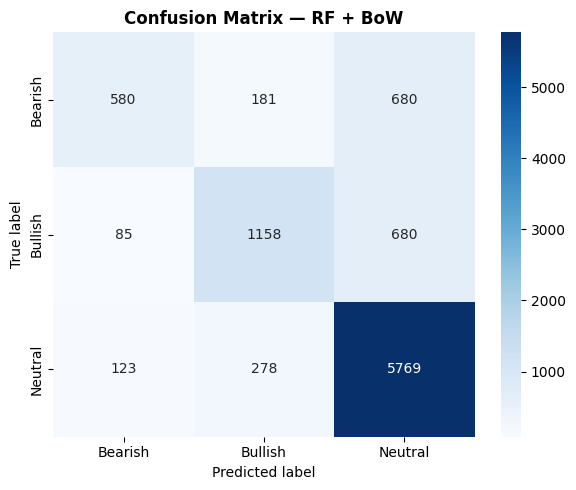

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier

classical_models = {
    'LR + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2)),
        ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'XGBoost + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2)),
        ('clf',   XGBClassifier(n_estimators=300, learning_rate=0.1,
                                eval_metric='mlogloss', random_state=42))
    ]),
    'MLP + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2)),
        ('clf',   MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                                random_state=42, early_stopping=True))
    ]),
    'RF + BoW': Pipeline([
        ('bow', CountVectorizer(max_features=15000, ngram_range=(1,1), min_df=2)),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        n_jobs=-1, random_state=42))
    ]),
}

for name, pipeline in classical_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-3'></a>
### 6.3 Traditional ML — Word2Vec Pipeline

Running CV: LR + Word2Vec...

=== LR + Word2Vec ===
              precision    recall  f1-score   support

     Bearish       0.26      0.33      0.29      1441
     Bullish       0.39      0.52      0.45      1923
     Neutral       0.81      0.67      0.74      6170

    accuracy                           0.59      9534
   macro avg       0.49      0.51      0.49      9534
weighted avg       0.64      0.59      0.61      9534



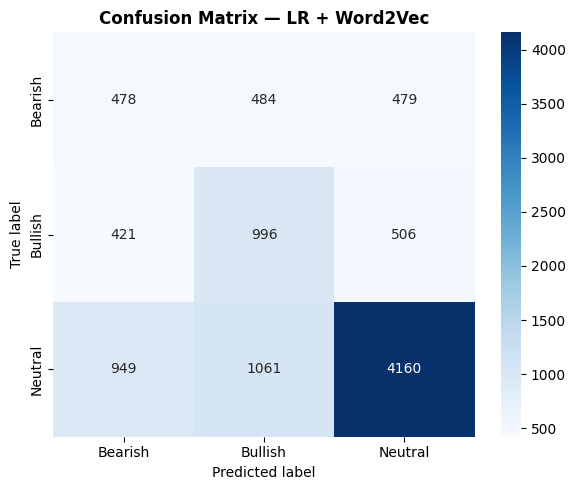

Running CV: MLP + Word2Vec...

=== MLP + Word2Vec ===
              precision    recall  f1-score   support

     Bearish       0.62      0.01      0.02      1441
     Bullish       0.50      0.34      0.40      1923
     Neutral       0.71      0.94      0.81      6170

    accuracy                           0.68      9534
   macro avg       0.61      0.43      0.41      9534
weighted avg       0.65      0.68      0.61      9534



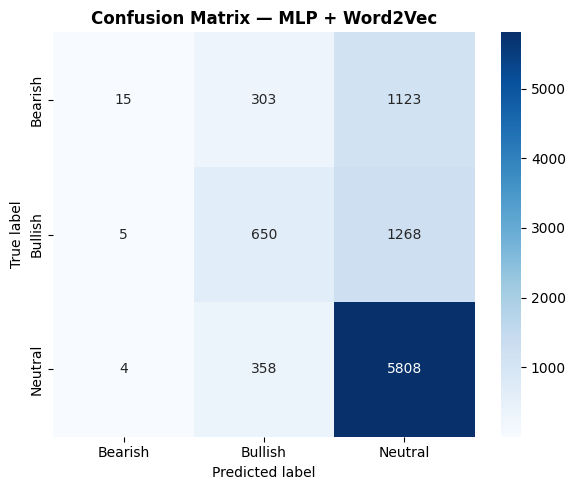

In [34]:
w2v_models = {
    'LR + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in w2v_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-4'></a>
### 6.4 Transformer Encoder + Classifier Head

In [35]:
# Extract FinBERT embeddings once (cache to avoid re-running)
print('Extracting FinBERT embeddings (this may take a few minutes)...')
X_finbert = get_transformer_embeddings(
    X_transformer.tolist(), model_name='ProsusAI/finbert', batch_size=32
)
print(f'FinBERT embedding shape: {X_finbert.shape}')

# Optional — extra credit (+0.50 pts each)
# X_bert    = get_transformer_embeddings(X_transformer.tolist(), model_name='bert-base-uncased')
# X_roberta = get_transformer_embeddings(X_transformer.tolist(), model_name='roberta-base')

Extracting FinBERT embeddings (this may take a few minutes)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding [ProsusAI/finbert]: 100%|██████████| 298/298 [03:56<00:00,  1.26it/s]

FinBERT embedding shape: (9534, 768)


Running CV: LR + FinBERT...

=== LR + FinBERT ===
              precision    recall  f1-score   support

     Bearish       0.56      0.72      0.63      1441
     Bullish       0.63      0.75      0.69      1923
     Neutral       0.90      0.78      0.84      6170

    accuracy                           0.77      9534
   macro avg       0.70      0.75      0.72      9534
weighted avg       0.79      0.77      0.78      9534



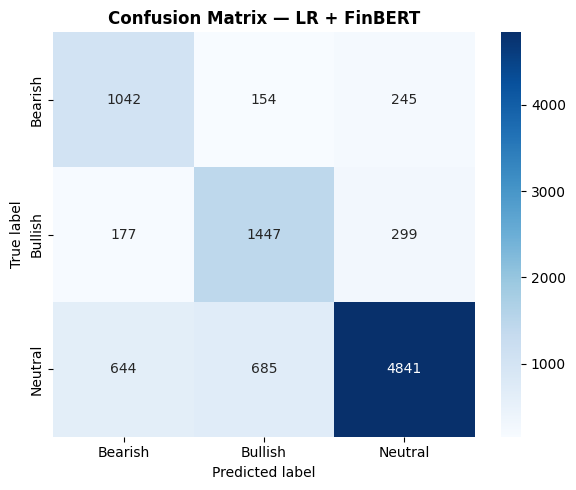

Running CV: MLP + FinBERT...

=== MLP + FinBERT ===
              precision    recall  f1-score   support

     Bearish       0.74      0.65      0.69      1441
     Bullish       0.76      0.74      0.75      1923
     Neutral       0.88      0.91      0.89      6170

    accuracy                           0.84      9534
   macro avg       0.79      0.77      0.78      9534
weighted avg       0.83      0.84      0.83      9534



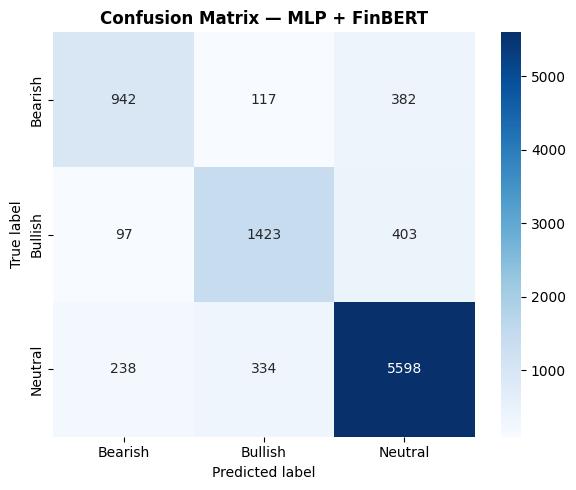

In [36]:
from sklearn.preprocessing import StandardScaler

encoder_models = {
    'LR + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(512,256), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in encoder_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_finbert, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-5'></a>
### 6.5 Fine-tuned FinBERT (End-to-end Transformer)

In [ ]:
# pip install transformers torch datasets
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset

MODEL_NAME = 'ProsusAI/finbert'
tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer_ft(batch['text'], padding='max_length',
                        truncation=True, max_length=128)

# Use fold 0 for fine-tuning demonstration
train_idx, val_idx = folds[0]
train_ds = Dataset.from_dict({'text': X_transformer.iloc[train_idx].tolist(),
                               'label': y.iloc[train_idx].tolist()})
val_ds   = Dataset.from_dict({'text': X_transformer.iloc[val_idx].tolist(),
                               'label': y.iloc[val_idx].tolist()})
train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

model_ft = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args = TrainingArguments(
    output_dir='./finbert_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=50,
    seed=42,
)
trainer = Trainer(model=model_ft, args=training_args,
                  train_dataset=train_ds, eval_dataset=val_ds)
trainer.train()
print('✅ FinBERT fine-tuning complete.')

Map:   0%|          | 0/7627 [00:00<?, ? examples/s]

Map:   0%|          | 0/1907 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.390357,0.431873
2,0.202571,0.446396


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
preds_ft   = trainer.predict(val_ds)
y_pred_ft  = preds_ft.predictions.argmax(axis=1)
y_true_ft  = y.iloc[val_idx].tolist()
res = evaluate_model(y_true_ft, y_pred_ft, model_name='FinBERT Fine-tuned')
results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='7'></a>
---
## 7. Evaluation & Analysis

### Metric Interpretation in Context

| Metric | Meaning |
|---|---|
| **Accuracy** | Overall correctness — misleading if classes are imbalanced |
| **F1-Macro** | Average F1 across all 3 classes with equal weight — **primary metric** |
| **F1-Weighted** | F1 weighted by class support — closer to accuracy |
| **Recall per class** | Missing a Bearish signal (low Recall) has real financial cost |
| **Precision per class** | Wrongly flagging Neutral as Bullish (low Precision) misleads investors |

In [ ]:
results_df = pd.DataFrame(results_table).sort_values('f1_macro', ascending=False)
results_df[['accuracy','f1_macro','f1_weighted']] = \
    results_df[['accuracy','f1_macro','f1_weighted']].round(4)
print(results_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
x     = range(len(results_df))
width = 0.28
ax.bar([i-width for i in x], results_df['accuracy'],    width, label='Accuracy',    color='#3498db', alpha=0.85)
ax.bar([i       for i in x], results_df['f1_macro'],    width, label='F1-Macro',    color='#2ecc71', alpha=0.85)
ax.bar([i+width for i in x], results_df['f1_weighted'], width, label='F1-Weighted', color='#e74c3c', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['model'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy · F1-Macro · F1-Weighted',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='8'></a>
---
## 8. Final Predictions on `test.csv`

Best model retrained on the **full training set**, then applied to `test.csv` → `pred_xx.csv`.

In [ ]:
# ── Retrain best classical model on full training data ────────────────────────
BEST_CLASSICAL = 'LR + TF-IDF'   # replace with whichever scored highest
best_pipeline  = classical_models[BEST_CLASSICAL]
best_pipeline.fit(X_classical, y)
print(f'✅ {BEST_CLASSICAL} retrained on full training set.')

In [ ]:
df_test = pd.read_csv('test.csv')
print(f'Test set shape: {df_test.shape}')
print(df_test.head())

X_test_classical   = preprocess_classical(df_test['text'].tolist())
X_test_transformer = preprocess_transformer(df_test['text'].tolist())
print('\n✅ Test set preprocessed (same pipeline, no re-fit).')

In [ ]:
# Option A: best classical model
preds_classical = best_pipeline.predict(X_test_classical)

# Option B: fine-tuned FinBERT (recommended if fine-tuning was run)
# test_ds = Dataset.from_dict({'text': X_test_transformer})
# test_ds = test_ds.map(tokenize_fn, batched=True)
# preds_final = trainer.predict(test_ds).predictions.argmax(axis=1)

final_preds = preds_classical   # replace with preds_final if fine-tuning done
print(f'Prediction distribution: {pd.Series(final_preds).value_counts().sort_index().to_dict()}')

In [ ]:
submission = pd.DataFrame({'id': df_test['id'], 'label': final_preds})
submission.to_csv('pred_xx.csv', index=False)
print('✅ Submission saved: pred_xx.csv')
print(submission.head(10))

[↑ Back to TOC](#toc)